# 01 - Real lanthanide line crowding (La II)

Phase 0C (`docs/babystep_plan.md` section 6).

**Question:** does line crowding on thermal-width velocity scales occur in modern
calibrated data? This does *not* prove Sobolev breakdown - it asks whether the
potentially problematic regime exists at all.

Deliverable: **Figure 2** - `P(dv_nearest)` for La II with reference widths at
1, 3, 10 km/s.

Data: GSI Database for Kilonova Radiative Transfer (Floers et al.), Zenodo record
19335084 - see `data/README.md` for provenance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sobolev import atomic_data as ad
from sobolev.constants import C

OUT = Path("../outputs"); OUT.mkdir(exist_ok=True)

lines = ad.load_gsi("../data/57LaII_transitions_calib.txt")
print(lines.shape)
lines[["WV_Transition", "Log(gf)", "Method_Lower", "Method_Upper"]].describe(include="all").head()

(17743, 19)


,WV_Transition,Log(gf),Method_Lower,Method_Upper
count,17743.000000,17743.00000,17743,17743
unique,NaN,NaN,2,2
top,NaN,NaN,shifted,shifted
freq,NaN,NaN,8900,16436
mean,9380.815173,-1.70651,NaN,NaN


## Two quality subsets

- **High confidence:** both levels experimentally matched (`xmatch`), `log gf > -1` -
  wavelengths reliable enough for overlap statistics on km/s scales.
- **Broader:** `xmatch` or `shifted` levels, `log gf > -2`.

(The calibrated La II file contains no `uncalib` levels, so "broader" here means
admitting `shifted` calibrations and weaker lines.)

In [2]:
both_xmatch = (lines["Method_Lower"] == "xmatch") & (lines["Method_Upper"] == "xmatch")
calibrated = lines["Method_Lower"].isin(["xmatch", "shifted"]) & lines[
    "Method_Upper"].isin(["xmatch", "shifted"])

high = lines[both_xmatch & (lines["Log(gf)"] > -1)]
broad = lines[calibrated & (lines["Log(gf)"] > -2)]
print(f"high-confidence subset: {len(high):>6d} lines")
print(f"broader subset:         {len(broad):>6d} lines")

high-confidence subset:    393 lines
broader subset:          10862 lines


## Nearest-neighbour velocity spacing -> Figure 2

Restrict to the optical-NIR window (3000 A - 3 um) where kilonova spectra are
actually observed; the full file extends to 21 um where line densities differ.

 high confidence: P(dv <    1 km/s) =   0.0%
 high confidence: P(dv <    3 km/s) =   0.0%
 high confidence: P(dv <   10 km/s) =   1.2%

         broader: P(dv <    1 km/s) =   1.0%
         broader: P(dv <    3 km/s) =   3.3%
         broader: P(dv <   10 km/s) =  11.3%



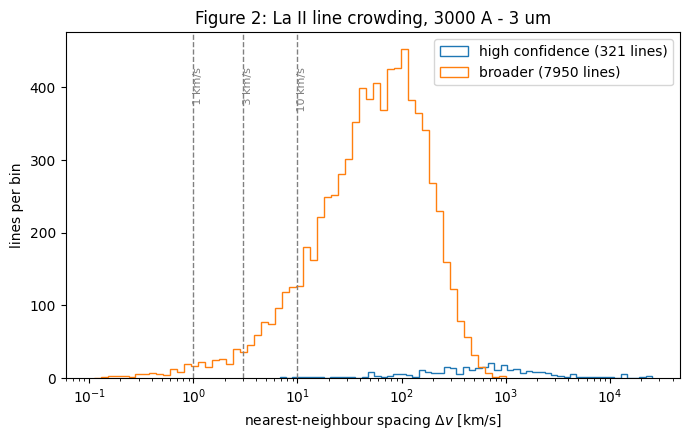

In [3]:
V_REFS_KMS = [1.0, 3.0, 10.0]
WINDOW = (3000.0, 30000.0)  # Angstrom

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, df, color in [("high confidence", high, "C0"), ("broader", broad, "C1")]:
    lam = df["WV_Transition"].to_numpy()
    lam = lam[(lam > WINDOW[0]) & (lam < WINDOW[1])]
    dv_kms = ad.nearest_neighbour_velocity_spacing(lam) / 1e5
    dv_kms = dv_kms[dv_kms > 0]  # identical wavelengths -> zero spacing
    bins = np.logspace(np.log10(max(dv_kms.min(), 1e-3)), np.log10(dv_kms.max()), 60)
    ax.hist(dv_kms, bins=bins, histtype="step", color=color,
            label=f"{name} ({len(lam)} lines)")
    for v in V_REFS_KMS:
        frac = np.mean(dv_kms < v)
        print(f"{name:>16s}: P(dv < {v:>4.0f} km/s) = {frac:6.1%}")
    print()

for v in V_REFS_KMS:
    ax.axvline(v, color="gray", ls="--", lw=1)
    ax.text(v, ax.get_ylim()[1] * 0.9, f" {v:g} km/s", rotation=90,
            va="top", fontsize=8, color="gray")
ax.set_xscale("log")
ax.set_xlabel(r"nearest-neighbour spacing $\Delta v$ [km/s]")
ax.set_ylabel("lines per bin")
ax.set_title("Figure 2: La II line crowding, 3000 A - 3 um")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig2_laII_line_spacing.png", dpi=200)

## Interpretation

The fraction of lines with a neighbour inside `Delta v < v_D` (printed above) is the
overlap statistic `O > 1` from plan doc section 6. If a non-negligible fraction of
even the *high-confidence* La II subset crowds within 1-10 km/s, the regime the
Sobolev treatment assumes away exists in real calibrated data - and this is a single
ion; blending across all lanthanides in mixed ejecta only adds lines.

Caveat (plan doc section 5): crowding is necessary, not sufficient, for transport
consequences. Whether overlap changes observables is the SEDONA question of
Weeks 3-4, not Phase 0.